# Combined-variation WZA Manhattan — SNP + small indel + SV (one plot)

kMate GrENE-Net **phase-1 replication**, matched **last_gen** pool set (355 pools).

Per-record GEA -> **WZA** (deg-7 SNP-number correction, Booker), run **separately per
variant class**, then **overlaid on a single Manhattan axis** so all variation is shown
together while each class stays distinguishable by marker:

- **dot (o)** = SNP
- **triangle (^)** = small indel
- **square (s)** = SV

y = -log10(WZA block p). CAM5 (block `2_1265`, Chr2 ~11.53 Mb) circled in green.

> Why per-class WZA and not one pooled WZA per block? WZA collapses every record in a
> block to a single block p-value. If we pooled SNP+indel+SV first we would get one mixed
> point per block and could no longer tell the classes apart. Running WZA *within* each
> class keeps the block-level test **and** the per-class markers — a block can appear up to
> three times (once per class present). No re-run of Kendall/LFMM is needed; we reuse the
> existing per-class WZA CSVs.

Two models, both shown:
- **Kendall-tau -> WZA** (raw association; no structure correction)
- **LFMM K=16 -> WZA** (structure-corrected; phase-1's other model)

> **One caveat on the y-axis.** The strongest block in the genome (`4_2519`, Chr4 ~12 Mb,
> weighted-Z ≈ 49) returns `Z_pVal == 0` — a **float64 underflow**, not a bad block: the
> normal-tail p `1 − Φ(z)` is exactly 0 once the SNP-number-corrected z exceeds ~38.5 (true
> in both the no-cap and cap-2000 deg-7 runs). It's the real Chr4 peak, so we **keep it**,
> floor its p, and **cap the y-axis** just above the strongest finite block; the underflowed
> point is drawn at the cap with a black outline + a `(p underflow)` label. The deg-7 SNP-number
> correction is the *phase-1* variant and is known in this project to inflate the tail relative
> to the canonical deg-2 — see `wza/` notes.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

WZA  = "/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/r2_gea_nonsnp/phase1_replication/results/wza"
PLOTS = "/global/home/users/tbellg/scratch/kmate/analysis/grenenet_gea/r2_gea_nonsnp/cam5_replication/plots"
TAG  = "deg7nocap"          # last_gen deg-7 no-cap WZA (matches phase1_replication notebook)
GEN, CLIMATE = 9, "bio1"     # gen9 = last_gen matched set; bio1 = annual mean temp
CHROMS = [f"Chr{i}" for i in range(1, 6)]
CAM5_BLOCK = "2_1265"

# (class key, marker, colour, label, point size, alpha, z-order)  -- SVs drawn on top, biggest.
# SNPs are the densest/most-numerous track, so we keep them readable (small but not too
# transparent) and ease off SV/indel opacity so the blue baseline isn't buried under red/orange.
CLASSES = [
    ("snp",        "o", "#2c6fbb", "SNP",          6,  0.40, 1),
    ("smallindel", "^", "#e08214", "small indel", 13,  0.45, 2),
    ("sv",         "s", "#d62728", "SV",          22,  0.60, 3),
]

def load(model, cls):
    w = pd.read_csv(f"{WZA}/wza_{model}_{cls}_gen{GEN}_{CLIMATE}_{TAG}.csv").rename(columns={"index": "block"})
    w["block"] = w["block"].astype(str)
    w = w[w["Z_pVal"].notna()].copy()
    w["chrom"] = w["chrom"].astype(str)
    w = w[w["chrom"].isin(CHROMS)]
    # Z_pVal==0 is a *float64 underflow*, not a degenerate block: 1-Phi(z)=0 once the
    # SNP-number-corrected z exceeds ~38.5. It happens at the single strongest block
    # (4_2519, Chr4 ~12 Mb, weighted-Z~49) — the real top peak — so we KEEP it and floor
    # the p, then cap the y-axis at plot time so this one point doesn't flatten the rest.
    w["underflow"] = w["Z_pVal"] <= 0
    nuf = int(w["underflow"].sum())
    if nuf:
        print(f"  {model}/{cls}: {nuf} block(s) with Z_pVal underflowed to 0 "
              f"(z>~38.5; floored & flagged): {list(w.loc[w.underflow,'block'])}")
    w["mlogp"] = -np.log10(w["Z_pVal"].clip(lower=1e-300))
    return w

def _offsets(data):
    allpos = pd.concat([d[["chrom", "pos"]] for d in data.values()])
    chrom_max = allpos.groupby("chrom")["pos"].max().reindex(CHROMS).fillna(0)
    offset  = chrom_max.cumsum().shift(1).fillna(0)
    centers = offset + chrom_max / 2
    return chrom_max, offset, centers

In [2]:
def manhattan_combined(model, ax=None, save=None):
    data = {c[0]: load(model, c[0]) for c in CLASSES}
    chrom_max, offset, centers = _offsets(data)
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(15, 5.5))

    # y-axis cap: a hair above the strongest FINITE (non-underflow) block, so the one
    # underflowed point (p floored to 0) plots as the tallest marker without squashing the rest.
    finite_max = max(d.loc[~d["underflow"], "mlogp"].max() for d in data.values())
    cap = np.ceil(finite_max) + 2

    # alternating chromosome bands
    for i, ch in enumerate(CHROMS):
        if i % 2 == 1:
            ax.axvspan(offset[ch], offset[ch] + chrom_max[ch], color="0.95", zorder=0)

    # one scatter per class (SNP bottom -> SV top); underflowed points pinned to the cap
    for cls, marker, color, label, size, alpha, zo in CLASSES:
        d = data[cls]; x = d["pos"] + d["chrom"].map(offset)
        y = d["mlogp"].clip(upper=cap)
        ax.scatter(x, y, s=size, marker=marker, c=color, alpha=alpha,
                   edgecolors="none", rasterized=True, zorder=zo, label=f"{label} ({len(d):,} blocks)")
        uf = d["underflow"]
        if uf.any():
            ax.scatter(x[uf], np.full(uf.sum(), cap), s=size * 3.5, marker=marker,
                       facecolors="none", edgecolors="black", linewidths=1.2, zorder=9)
            for xx, blk in zip(x[uf], d.loc[uf, "block"]):
                ax.annotate(f"{blk}\n(p underflow)", (xx, cap), color="black", fontsize=8,
                            ha="center", va="bottom", xytext=(0, 3), textcoords="offset points")

    # per-class Bonferroni thresholds (0.05 / n_blocks_in_class)
    for cls, marker, color, label, *_ in CLASSES:
        n = len(data[cls])
        ax.axhline(-np.log10(0.05 / n), color=color, lw=0.9, ls="--", alpha=0.65, zorder=4)

    # CAM5 highlight (present in SNP/indel; no SV record in 2_1265)
    cam_y = []
    for cls, marker, color, label, *_ in CLASSES:
        d = data[cls]; c5 = d[d["block"] == CAM5_BLOCK]
        if len(c5):
            x = c5["pos"] + c5["chrom"].map(offset)
            ax.scatter(x, c5["mlogp"], s=160, facecolors="none", edgecolors="green",
                       linewidths=1.8, zorder=10)
            cam_y.append((float(x.iloc[0]), float(c5["mlogp"].iloc[0])))
    if cam_y:
        xc, yc = max(cam_y, key=lambda t: t[1])
        ax.annotate("CAM5\n(2_1265)", (xc, yc), color="green", fontsize=10, fontweight="bold",
                    xytext=(8, 10), textcoords="offset points")

    ax.set_xticks(centers); ax.set_xticklabels(CHROMS)
    ax.set_xlabel("genome position (LD-block)")
    ax.set_ylabel("-log10(WZA block p)")
    ax.set_xlim(0, (offset + chrom_max).max())
    ax.set_ylim(0, cap + max(1.0, 0.10 * cap))
    ax.margins(x=0)
    ttl = {"kendall": "Kendall-\u03c4 \u2192 WZA (raw association)",
           "lfmm": "LFMM K=16 \u2192 WZA (structure-corrected)"}[model]
    ax.set_title(f"{ttl}  \u2014  last_gen, bio1, deg-7", loc="left", fontsize=12)

    # legend: class markers + threshold note
    handles = [Line2D([0],[0], marker=c[1], color="w", markerfacecolor=c[2], markersize=9,
                      label=f"{c[3]} ({len(data[c[0]]):,})") for c in CLASSES]
    handles.append(Line2D([0],[0], color="0.4", lw=0.9, ls="--", label="per-class Bonferroni 0.05/n"))
    handles.append(Line2D([0],[0], marker="o", color="w", markeredgecolor="green",
                          markerfacecolor="none", markersize=11, label="CAM5 block 2_1265"))
    ax.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.92, ncol=1)

    if own_fig:
        fig.tight_layout()
        if save:
            fig.savefig(save, dpi=200, bbox_inches="tight")
            fig.savefig(save.replace(".png", ".pdf"), bbox_inches="tight")
            print("saved", save)
        plt.show()
    return data

## Kendall-τ → WZA (raw association) — all variation combined

  kendall/smallindel: 1 block(s) with Z_pVal underflowed to 0 (z>~38.5; floored & flagged): ['4_2519']


saved /global/home/users/tbellg/scratch/kmate/analysis/grenenet_gea/r2_gea_nonsnp/cam5_replication/plots/manhattan_combined_kendall.png


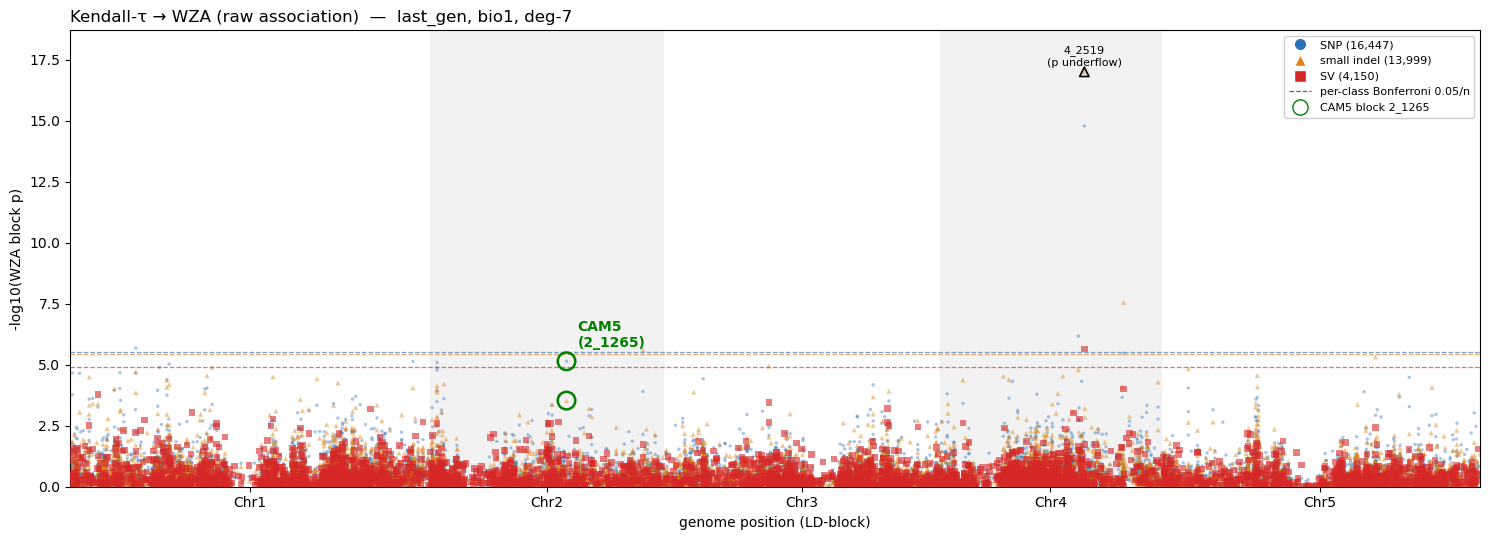

In [3]:
_ = manhattan_combined("kendall", save=f"{PLOTS}/manhattan_combined_kendall.png")

## LFMM (K=16) → WZA (structure-corrected) — all variation combined

saved /global/home/users/tbellg/scratch/kmate/analysis/grenenet_gea/r2_gea_nonsnp/cam5_replication/plots/manhattan_combined_lfmm.png


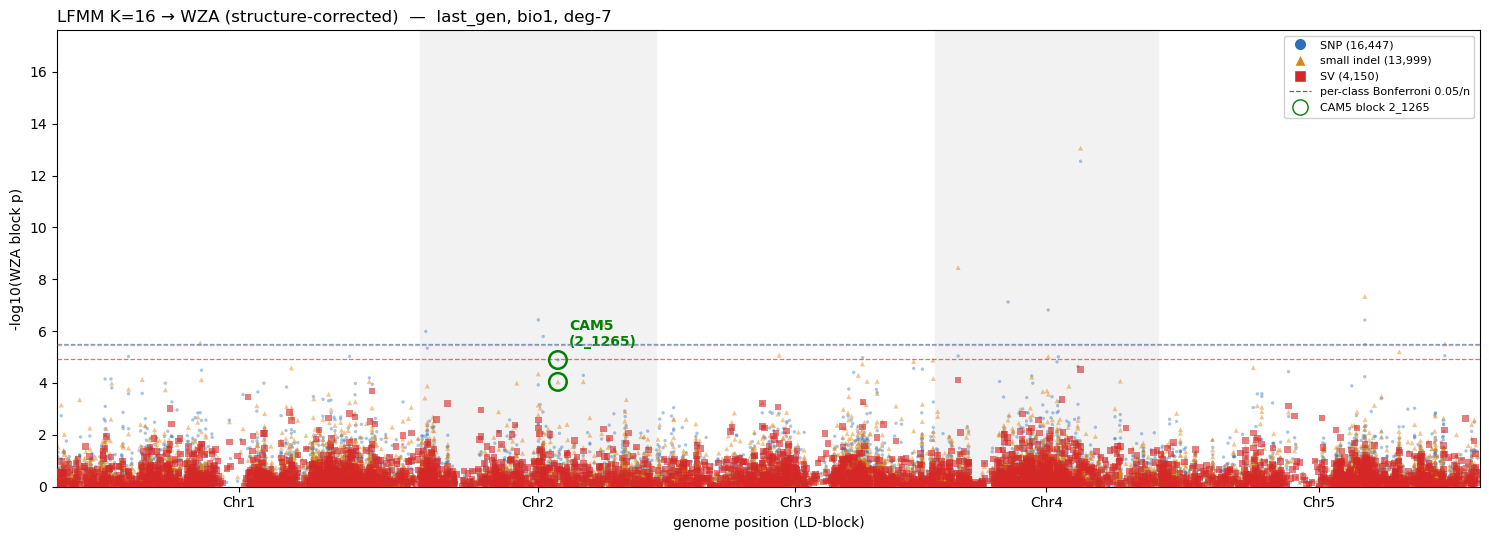

In [4]:
_ = manhattan_combined("lfmm", save=f"{PLOTS}/manhattan_combined_lfmm.png")

## Both models, stacked (single figure for the talk)

  kendall/smallindel: 1 block(s) with Z_pVal underflowed to 0 (z>~38.5; floored & flagged): ['4_2519']


saved /global/home/users/tbellg/scratch/kmate/analysis/grenenet_gea/r2_gea_nonsnp/cam5_replication/plots/manhattan_combined_both.png


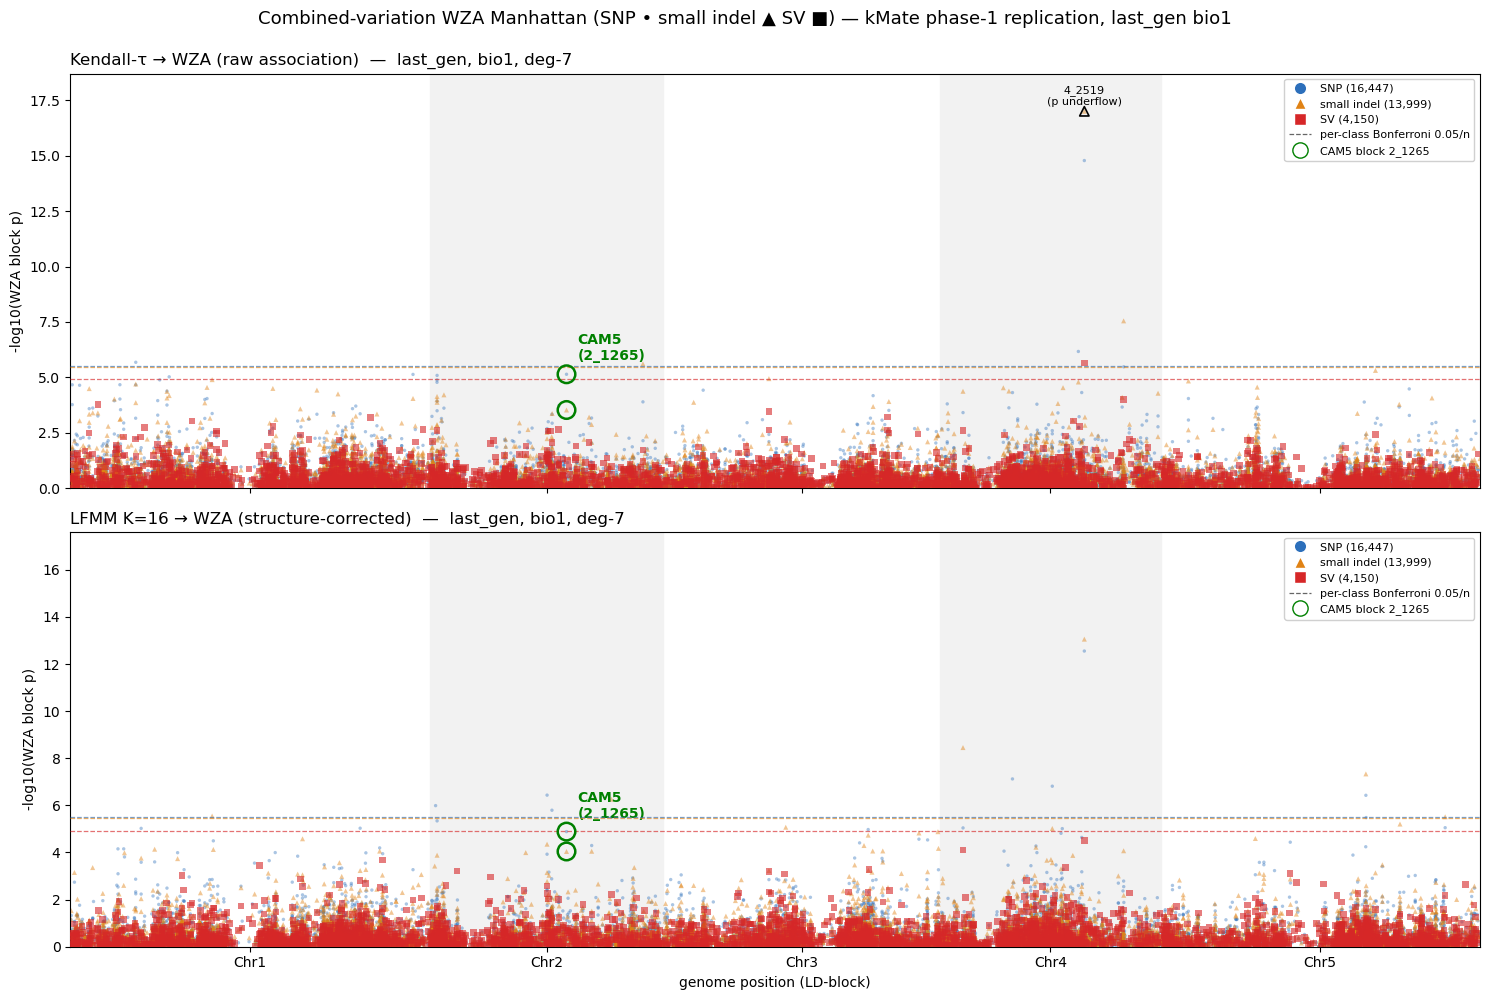

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
manhattan_combined("kendall", ax=axes[0])
manhattan_combined("lfmm", ax=axes[1])
axes[0].set_xlabel("")
fig.suptitle("Combined-variation WZA Manhattan (SNP \u2022 small indel \u25b2 SV \u25a0) \u2014 kMate phase-1 replication, last_gen bio1",
             y=0.995, fontsize=13)
fig.tight_layout()
fig.savefig(f"{PLOTS}/manhattan_combined_both.png", dpi=200, bbox_inches="tight")
fig.savefig(f"{PLOTS}/manhattan_combined_both.pdf", bbox_inches="tight")
print("saved", f"{PLOTS}/manhattan_combined_both.png")
plt.show()

## Summary table (per class, both models)

In [6]:
def bh_q(p):
    p = np.asarray(p, float); n = len(p); o = np.argsort(p); q = np.empty(n)
    q[o] = (p[o] * n) / (np.arange(n) + 1); q[o] = np.minimum.accumulate(q[o][::-1])[::-1]
    return np.clip(q, 0, 1)

rows = []
for model in ["kendall", "lfmm"]:
    for cls, *_ in CLASSES:
        w = load(model, cls).sort_values("Z_pVal").reset_index(drop=True); n = len(w)
        p = w["Z_pVal"].to_numpy(); q = bh_q(p); r = w.index[w["block"] == CAM5_BLOCK]
        rows.append(dict(model=model, cls=cls, blocks=n,
                         Bonf=int((p < 0.05 / n).sum()), BH_q05=int((q < 0.05).sum()),
                         CAM5_rank=(int(r[0]) + 1 if len(r) else None),
                         CAM5_p=(f"{w.loc[r[0],'Z_pVal']:.2e}" if len(r) else "absent"),
                         CAM5_q=(round(float(q[int(r[0])]), 3) if len(r) else None)))
pd.DataFrame(rows)

  kendall/smallindel: 1 block(s) with Z_pVal underflowed to 0 (z>~38.5; floored & flagged): ['4_2519']


,model,cls,blocks,Bonf,BH_q05,CAM5_rank,CAM5_p,CAM5_q
0,kendall,snp,16447,3,20,5.0,7.25e-06,0.019
1,kendall,smallindel,13999,3,31,41.0,2.96e-04,0.101
2,kendall,sv,4150,1,1,NaN,absent,NaN
3,lfmm,snp,16447,7,35,17.0,1.30e-05,0.013
4,lfmm,smallindel,13999,6,26,26.0,9.06e-05,0.049
5,lfmm,sv,4150,0,0,NaN,absent,NaN
